In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [5]:
df = pd.read_csv("Adidas US Sales Datasets.csv", header=4)
df.head()


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,01-01-2020,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","$6,00,000","$3,00,000",50%,In-store
1,Foot Locker,1185732,02-01-2020,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","$5,00,000","$1,50,000",30%,In-store
2,Foot Locker,1185732,03-01-2020,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","$4,00,000","$1,40,000",35%,In-store
3,Foot Locker,1185732,04-01-2020,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$3,82,500","$1,33,875",35%,In-store
4,Foot Locker,1185732,05-01-2020,Northeast,New York,New York,Men's Apparel,$60.00,900,"$5,40,000","$1,62,000",30%,In-store


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Khushi Chaudhary\AppData\Local\Temp\ipykernel_10320\1615027350.py:5: SyntaxWarning: invalid escape sequence '\$'
  df["Total Sales"] = df["Total Sales"].replace('[\$,]', '', regex=True).astype(float)


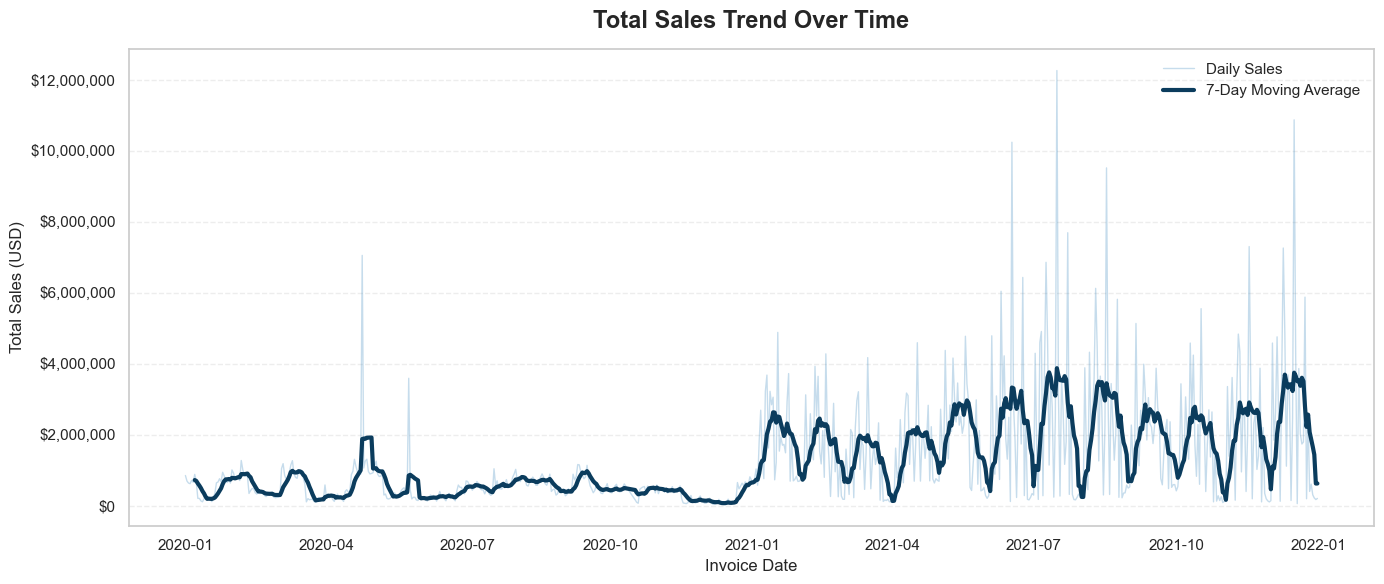

In [15]:
import matplotlib.ticker as mtick

# Ensure correct formats
df["Invoice Date"] = pd.to_datetime(df["Invoice Date"], dayfirst=True)
df["Total Sales"] = df["Total Sales"].replace('[\$,]', '', regex=True).astype(float)

# Aggregate daily sales
daily_sales = df.groupby("Invoice Date")["Total Sales"].sum().reset_index()

# 🔑 Add rolling average ONLY for visualization (no data loss)
daily_sales["7_day_avg"] = daily_sales["Total Sales"].rolling(window=7).mean()

plt.figure(figsize=(14,6))

# Raw daily sales (light & thin)
plt.plot(
    daily_sales["Invoice Date"],
    daily_sales["Total Sales"],
    color="#1f77b4",
    alpha=0.25,
    linewidth=1,
    label="Daily Sales"
)

# Smoothed trend line (bold & clean)
plt.plot(
    daily_sales["Invoice Date"],
    daily_sales["7_day_avg"],
    color="#0b3c5d",
    linewidth=3,
    label="7-Day Moving Average"
)

plt.title("Total Sales Trend Over Time", fontsize=17, fontweight="bold", pad=15)
plt.xlabel("Invoice Date", fontsize=12)
plt.ylabel("Total Sales (USD)", fontsize=12)

# Currency formatting
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Clean grid
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.grid(axis="x", visible=False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


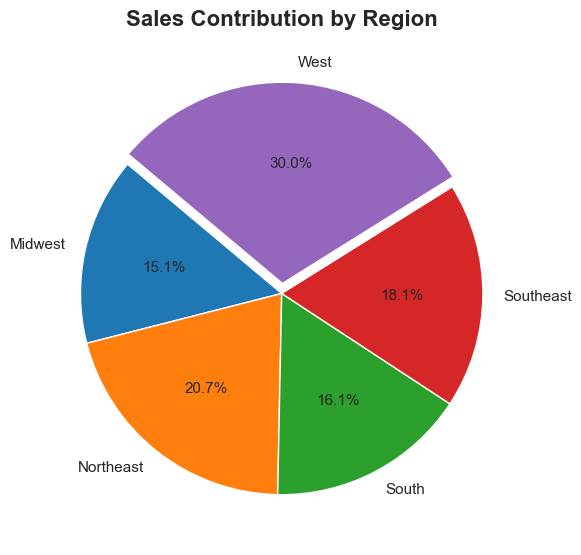

In [20]:
# Aggregate sales by region
region_sales = df.groupby("Region")["Total Sales"].sum()

plt.figure(figsize=(6,6))   # 👈 size reduced

# Professional contrasting color palette
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=[0.05 if i == region_sales.idxmax() else 0 for i in region_sales.index],
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 11}
)

plt.title(
    "Sales Contribution by Region",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.ylabel("")
plt.tight_layout()
plt.show()


In [23]:
cols_to_clean = [
    "Price per Unit",
    "Units Sold",
    "Total Sales",
    "Operating Profit"
]

for col in cols_to_clean:
    df[col] = (
        df[col]
        .replace('[\$,]', '', regex=True)
        .astype(float)
    )


<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Khushi Chaudhary\AppData\Local\Temp\ipykernel_10320\2351305829.py:11: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


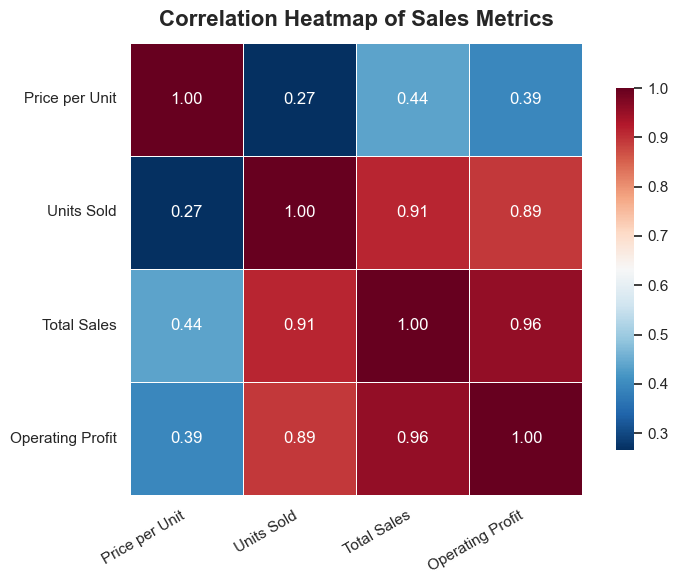

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
corr_data = df[
    ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit"]
]

# Correlation matrix
corr_matrix = corr_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Sales Metrics",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()
